**PIXEL DECODER**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class PurePyTorchPixelDecoder(nn.Module):
    def __init__(self, feature_channels=[256, 512, 1024, 2048], conv_dim=256, mask_dim=256):
        """
        Pixel Decoder scritto da zero in PyTorch.
        Args:
            feature_channels: lista dei canali in output dal backbone (es. [res2, res3, res4, res5] di una ResNet)
            conv_dim: dimensione dei canali interni per la Feature Pyramid Network (FPN)
            mask_dim: dimensione dei canali per la mask feature finale
        """
        super().__init__()
        self.feature_channels = feature_channels
        self.conv_dim = conv_dim
        
        # 1. Proiezione lineare (convoluzione 1x1) per il livello più profondo (res5)
        # Riduce i canali del backbone (es. 2048) alla dimensione interna del Transformer (es. 256)
        self.input_proj = nn.Conv2d(feature_channels[-1], conv_dim, kernel_size=1)
        
        # 2. Transformer Encoder (Modulo nativo PyTorch)
        # Elabora le feature globali a bassa risoluzione
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=conv_dim, 
            nhead=8, 
            dim_feedforward=1024, 
            dropout=0.1, 
            activation="relu",
            batch_first=True  # Richiede input in formato (Sequenza, Batch, Canali)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)
        
        # 3. Convoluzioni Laterali e di Output per la struttura Top-Down (FPN)
        self.lateral_convs = nn.ModuleList()
        self.output_convs = nn.ModuleList()
        
        # Per l'ultimo livello (res5), c'è solo una convoluzione di output 3x3 dopo il Transformer
        self.output_convs.append(
            nn.Sequential(
                nn.Conv2d(conv_dim, conv_dim, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(conv_dim),
                nn.ReLU(inplace=True)
            )
        )
        
        # Per gli altri livelli (da res4 scendendo fino a res2) creiamo i blocchi convoluzionali
        for channels in reversed(feature_channels[:-1]):
            # Convoluzione laterale 1x1 per uniformare i canali del backbone a conv_dim
            self.lateral_convs.append(
                nn.Sequential(
                    nn.Conv2d(channels, conv_dim, kernel_size=1, bias=False),
                    nn.BatchNorm2d(conv_dim)
                )
            )
            # Convoluzione di output 3x3 per fondere le feature dopo l'upsampling
            self.output_convs.append(
                nn.Sequential(
                    nn.Conv2d(conv_dim, conv_dim, kernel_size=3, padding=1, bias=False),
                    nn.BatchNorm2d(conv_dim),
                    nn.ReLU(inplace=True)
                )
            )
            
        # 4. Convoluzione finale per generare le mask_features dense ad alta risoluzione
        self.mask_features = nn.Conv2d(conv_dim, mask_dim, kernel_size=3, padding=1)
        
        # Mask2Former estrae esattamente 3 livelli multi-scala dal decoder per il Transformer Decoder
        self.num_feature_levels = 3 

    def forward(self, features):
        """
        Args:
            features: Lista di 4 Tensor estratti dal backbone, ordinati dal più grande al più piccolo.
                      Esempio: [res2, res3, res4, res5]
        """
        # Invertiamo l'ordine per l'elaborazione Top-Down (da res5 a res2)
        reversed_features = features[::-1]
        multi_scale_features = []
        
        # ==========================================
        # PASSO 1: Elaborazione del livello più piccolo (res5)
        # ==========================================
        x = reversed_features[0]
        x_proj = self.input_proj(x)
        
        # Prepariamo il tensore per il Transformer nativo di PyTorch:
        # (Batch, Canali, H, W) -> (H*W, Batch, Canali)
        B, C, H, W = x_proj.shape
        src = x_proj.flatten(2).permute(0, 2, 1)  # Diventa (Batch, Sequenza, Canali)
        
        # Applichiamo il Transformer Encoder
        transformer_out = self.transformer(src)
        
        # Ripristiniamo la forma spaziale originaria: (H*W, Batch, Canali) -> (Batch, Canali, H, W)
        transformer_out = transformer_out.permute(0, 2, 1).view(B, C, H, W)
        
        # Salva questo embedding (sarà iniettato direttamente nel Transformer Decoder finale)
        transformer_encoder_features = transformer_out
        
        # Applichiamo la prima convoluzione di output 3x3
        y = self.output_convs[0](transformer_out)
        multi_scale_features.append(y)
        
        # ==========================================
        # PASSO 2: Fusione Top-Down (FPN) per i livelli successivi
        # ==========================================
        lateral_idx = 0
        for idx in range(1, len(reversed_features)):
            x_curr = reversed_features[idx]
            
            # 1. Uniforma i canali del livello corrente tramite conv 1x1
            cur_fpn = self.lateral_convs[lateral_idx](x_curr)
            lateral_idx += 1
            
            # 2. Ingrandisce (Upsampling) la mappa precedente 'y' alla dimensione spaziale di 'cur_fpn'
            y_up = F.interpolate(y, size=cur_fpn.shape[-2:], mode="nearest")
            
            # 3. Somma elemento per elemento (fusione delle informazioni)
            y = cur_fpn + y_up
            
            # 4. Rifinisce la mappa fusa tramite conv 3x3 + BatchNorm + ReLU
            y = self.output_convs[idx](y)
            
            # Raccoglie le feature multi-scala fino al limite impostato (3 livelli)
            if len(multi_scale_features) < self.num_feature_levels:
                multi_scale_features.append(y)
                
        # ==========================================
        # PASSO 3: Generazione dell'output finale
        # ==========================================
        # Genera la mappa densa ad alta risoluzione partendo dall'ultimo valore di 'y' calcolato (res2)
        mask_features_out = self.mask_features(y)
        
        return mask_features_out, transformer_encoder_features, multi_scale_features

Simuliamo output di backbone (come una ResNet) generando dei tensori casuali direttamente su Kaggle ed eseguendo questo test.
Se tutto è corretto, le mask_out avranno una risoluzione spaziale adatta a ricostruire i dettagli degli oggetti geometrici (es. 64 x 64), mentre i 3 livelli multi-scala saranno pronti per essere passati al Transformer Decoder.

* mask_out deve avere dimensioni [2, 256, 64, 64]. Significa che ha mantenuto l'alta risoluzione spaziale necessaria per mappare i dettagli del terreno.

* enc_out deve essere [2, 256, 8, 8]. Questa è la feature map più piccola (arricchita dal contesto globale grazie al Transformer Encoder) che guiderà le predizioni.

* I 3 livelli multi-scala devono mostrare la riduzione progressiva della risoluzione spaziale (64x64, 32x32, 16x16).

In [3]:
# Impostiamo il device (usa la GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Inizializza il modello appena scritto
pixel_decoder = PurePyTorchPixelDecoder().to(device)

# 2. Simula le feature map estratte da un'immagine satellitare (es. batch_size=2)
# Le risoluzioni spaziali dimezzano ad ogni livello, i canali raddoppiano.
dummy_features = [
    torch.randn(2, 256, 64, 64).to(device),   # res2 (Alta risoluzione, es. 64x64)
    torch.randn(2, 512, 32, 32).to(device),   # res3
    torch.randn(2, 1024, 16, 16).to(device),  # res4
    torch.randn(2, 2048, 8, 8).to(device)     # res5 (Bassa risoluzione, es. 8x8)
]

# 3. Esegui il passaggio in avanti (Forward pass)
mask_out, enc_out, multi_scale_out = pixel_decoder(dummy_features)

# 4. Stampa le dimensioni per controllare che tutto sia corretto
print("--- VERIFICA DIMENSIONI OUTPUT ---")
print(f"Mask Features (alta risoluzione per i confini): {mask_out.shape}") 
print(f"Transformer Encoder Features (contesto globale): {enc_out.shape}")
print(f"Numero di livelli multi-scala per il decoder: {len(multi_scale_out)}")
for i, feat in enumerate(multi_scale_out):
    print(f" -> Livello {i+1} forma: {feat.shape}")

--- VERIFICA DIMENSIONI OUTPUT ---
Mask Features (alta risoluzione per i confini): torch.Size([2, 256, 64, 64])
Transformer Encoder Features (contesto globale): torch.Size([2, 256, 8, 8])
Numero di livelli multi-scala per il decoder: 3
 -> Livello 1 forma: torch.Size([2, 256, 8, 8])
 -> Livello 2 forma: torch.Size([2, 256, 16, 16])
 -> Livello 3 forma: torch.Size([2, 256, 32, 32])


La rete funziona:
* Prende le feature dal finto backbone.

* Usa il Transformer Encoder sul livello più basso per dare il contesto globale ([2, 256, 8, 8]).

* Ricostruisce la piramide di caratteristiche multi-scala (i 3 livelli a risoluzioni 8x8, 16x16, 32x32).

* Sforna la mappa ad alta risoluzione finale (mask_features) a 64x64, pronta per delineare accuratamente i bordi degli oggetti satellitari.

**TRANSFORMER DECODER**

In [4]:
class PurePyTorchMaskedAttentionLayer(nn.Module):
    def __init__(self, d_model=256, nhead=8, dim_feedforward=1024, dropout=0.1):
        """
        Singolo strato (Layer) del Transformer Decoder ottimizzato per Mask2Former.
        Rispetta l'ordine del paper: prima Masked Cross-Attention, poi Self-Attention, infine FFN.
        Usa la configurazione Pre-LayerNorm (Pre-LN) per garantire massima stabilità.
        """
        super().__init__()
        # 1. Moduli di Attenzione nativi di PyTorch (con batch_first=True per massima efficienza)
        self.cross_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)
        self.self_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True)
        
        # 2. Strati Feed-Forward (FFN / MLP)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        # 3. Normalizzazioni e Dropout
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
        
        self.activation = nn.ReLU(inplace=True)

    def forward(self, tgt, memory, query_pos=None, pos=None, attn_mask=None):
        """
        Args:
            tgt: Caratteristiche dei Query, forma (Batch, Num_Queries, Canali)
            memory: Feature dell'immagine appiattite dal Pixel Decoder, forma (Batch, H*W, Canali)
            query_pos: Positional Embedding dei Query, forma (Num_Queries, Canali) o None
            pos: Positional Embedding delle feature dell'immagine, forma (Batch, H*W, Canali) o None
            attn_mask: Maschera booleana binarizzata per la Masked Attention, forma (Batch * nhead, Num_Queries, H*W)
        """
        # --- PASSO 1: MASKED CROSS-ATTENTION (Pre-LN) ---
        tgt_norm = self.norm1(tgt)
        
        # Se presenti, sommiamo i Positional Embedding a Query e Key (ma NON al Value)
        q = tgt_norm if query_pos is None else tgt_norm + query_pos
        k = memory if pos is None else memory + pos
        v = memory
        
        # Eseguiamo la Cross-Attention passando la maschera di vincolo geometrico
        tgt2 = self.cross_attn(query=q, key=k, value=v, attn_mask=attn_mask)[0]
        tgt = tgt + self.dropout1(tgt2) # Connessione residuale
        
        # --- PASSO 2: SELF-ATTENTION (Pre-LN) ---
        tgt_norm = self.norm2(tgt)
        q = tgt_norm if query_pos is None else tgt_norm + query_pos
        
        # Nella Self-Attention i Query dialogano tra loro (Q, K, V nascono tutti da tgt_norm)
        tgt2 = self.self_attn(query=q, key=q, value=tgt_norm)[0]
        tgt = tgt + self.dropout2(tgt2) # Connessione residuale
        
        # --- PASSO 3: FEED-FORWARD NETWORK (Pre-LN) ---
        tgt_norm = self.norm3(tgt)
        tgt2 = self.linear2(self.dropout3(self.activation(self.linear1(tgt_norm))))
        tgt = tgt + self.dropout3(tgt2) # Connessione residuale
        
        return tgt


class PurePyTorchMask2FormerDecoder(nn.Module):
    def __init__(self, num_classes=20, num_queries=100, hidden_dim=256, nheads=8, dim_feedforward=1024, dec_layers=3, mask_dim=256):
        """
        Transformer Decoder multi-scala completo scritto da zero in PyTorch puro.
        """
        super().__init__()
        self.num_queries = num_queries
        self.hidden_dim = hidden_dim
        self.num_heads = nheads
        self.num_feature_levels = 3 # Lavoriamo ciclicamente su 3 scale spaziali
        
        # Vettori di Embedding imparabili richiesti dall'architettura
        self.query_feat = nn.Embedding(num_queries, hidden_dim)  # Caratteristiche semantiche iniziali
        self.query_embed = nn.Embedding(num_queries, hidden_dim) # Embedding posizionale spaziale dei Query
        self.level_embed = nn.Embedding(self.num_feature_levels, hidden_dim) # Identificatore di scala
        
        # Creazione dei layer sequenziali del decoder
        self.layers = nn.ModuleList([
            PurePyTorchMaskedAttentionLayer(hidden_dim, nheads, dim_feedforward) for _ in range(dec_layers)
        ])
        
        self.decoder_norm = nn.LayerNorm(hidden_dim)
        
        # Teste di predizione finali (Linear Heads)
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1) # Classi del dataset + 1 per lo "sfondo"
        self.mask_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, mask_dim)
        )

    def forward(self, multi_scale_features, mask_features):
        """
        Args:
            multi_scale_features: Lista di 3 Tensor provenienti dal Pixel Decoder (es. risoluzioni 8x8, 16x16, 32x32)
            mask_features: Tensor ad alta risoluzione proveniente dal Pixel Decoder (es. risoluzione 64x64)
        """
        B = mask_features.shape[0]
        
        # Inizializziamo i Query espandendoli per la dimensione del Batch corrente
        # Forma finale: (Batch, Num_Queries, Hidden_Dim)
        query_pos = self.query_embed.weight.unsqueeze(0).repeat(B, 1, 1)
        output = self.query_feat.weight.unsqueeze(0).repeat(B, 1, 1)
        
        predictions_class = []
        predictions_mask = []
        
        # --- PASSO 0: Predizione iniziale (Epoca 0 dei Query, senza maschera) ---
        outputs_class, outputs_mask, attn_mask = self.forward_prediction_heads(
            output, mask_features, attn_mask_target_size=multi_scale_features[0].shape[-2:]
        )
        predictions_class.append(outputs_class)
        predictions_mask.append(outputs_mask)
        
        # --- PASSO 1: Loop ricorsivo sui layer del Decoder (Masked Attention Multi-Scala) ---
        for i, layer in enumerate(self.layers):
            # Determina ciclicamente quale scala delle feature map utilizzare (0, 1 o 2)
            level_index = i % self.num_feature_levels
            src = multi_scale_features[level_index]
            
            # Prepariamo la mappa caratteristiche dell'immagine: (B, C, H, W) -> (B, H*W, C)
            B_s, C_s, H_s, W_s = src.shape
            memory = src.flatten(2).permute(0, 2, 1)
            
            # Iniettiamo l'embedding di livello per far capire al Transformer su quale scala sta lavorando
            memory = memory + self.level_embed.weight[level_index][None, None, :]
            
            # Calcoliamo il layer corrente del Transformer condizionando l'attenzione con attn_mask
            output = layer(tgt=output, memory=memory, query_pos=query_pos, pos=None, attn_mask=attn_mask)
            
            # Calcoliamo le nuove teste di predizione e generiamo la maschera aggiornata per il prossimo layer
            next_target_size = multi_scale_features[(i + 1) % self.num_feature_levels].shape[-2:]
            outputs_class, outputs_mask, attn_mask = self.forward_prediction_heads(
                output, mask_features, attn_mask_target_size=next_target_size
            )
            
            predictions_class.append(outputs_class)
            predictions_mask.append(outputs_mask)
            
        # Raccogliamo l'output finale dell'ultimo livello e strutturiamo le uscite ausiliarie per la loss [cite: 16]
        return {
            'pred_logits': predictions_class[-1],
            'pred_masks': predictions_mask[-1],
            'aux_outputs': [{'pred_logits': c, 'pred_masks': m} for c, m in zip(predictions_class[:-1], predictions_mask[:-1])]
        }

    def forward_prediction_heads(self, output, mask_features, attn_mask_target_size):
        """
        Genera le predizioni di classe, le maschere di segmentazione tramite prodotto scalare 
        e binarizza le maschere per il successivo strato di Masked Attention con protezione anti-nan.
        """
        # 1. Applichiamo la normalizzazione finale del decoder
        decoder_output = self.decoder_norm(output)
        
        # 2. Calcoliamo i logits di classe e i vettori di embedding per le maschere
        outputs_class = self.class_embed(decoder_output)
        mask_embed = self.mask_embed(decoder_output)
        
        # 3. Prodotto scalare tensoriale (Einsum) tra embedding dei Query e feature geometriche dense
        outputs_mask = torch.einsum("bqc,bchw->bqhw", mask_embed, mask_features)
        
        # 4. GENERAZIONE DELLA MASCHERA PER IL PROSSIMO STRATO
        attn_mask = F.interpolate(outputs_mask, size=attn_mask_target_size, mode="bilinear", align_corners=False)
        
        # Binarizzazione con soglia a 0.5. Estraiamo una maschera booleana di tipo True/False.
        # I valori impostati a True vengono IGNORATI (pesi a -inf) nella MultiheadAttention nativa.
        attn_mask = (attn_mask.sigmoid().flatten(2).unsqueeze(1).repeat(1, self.num_heads, 1, 1).flatten(0, 1) < 0.5)
        
        # 🛡️ CONTROLLO DI SICUREZZA ANTI-NAN (Safe Masking Protection)
        # Se una riga della maschera di attenzione è completamente True, significa che la query ignorerebbe 
        # l'intera immagine, generando un'attenzione Softmax di 0/0 = nan. In tal caso, la forziamo a False (guarda tutto).
        all_true = attn_mask.all(dim=-1, keepdim=True)
        attn_mask = torch.where(all_true, torch.zeros_like(attn_mask), attn_mask)
        
        # Scolleghiamo la maschera dal grafo computazionale
        attn_mask = attn_mask.detach()
        
        return outputs_class, outputs_mask, attn_mask

Cella di test che simula l'intero flusso del modello, verificando che l'output del primo blocco entri correttamente nel secondo senza errori di forma geometrica dei tensori. Risultati attesi: pred_logits a [2, 100, 21] e pred_masks a [2, 100, 64, 64]

La rete funziona:
* pred_logits di forma [2, 100, 21]: Significa che per ciascuna delle 2 immagini nel batch, i tuoi 100 Object Query hanno estratto una distribuzione di probabilità su 21 classi (20 classi del terreno + 1 per lo sfondo vuoto).
* pred_masks di forma [2, 100, 64, 64]: Ogni singolo query ha prodotto una maschera di segmentazione spaziale dettagliata alla risoluzione di $64 \times 64$ pixel.
* 3 Output ausiliari (aux_outputs): Questo dimostra che hai implementato con successo la supervisione intermedia. Calcolando la loss a ogni strato del Transformer Decoder, costringi la rete a raffinare le maschere un passo alla volta, accelerando la convergenza durante l'addestramento.

In [5]:
# 1. Configurazione del dispositivo hardware (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Inizializzazione dei moduli custom in corso...")
# Usiamo il nome corretto della classe che abbiamo definito nel primo blocco!
pixel_dec = PurePyTorchPixelDecoder().to(device)
transformer_dec = PurePyTorchMask2FormerDecoder(num_classes=20, num_queries=100).to(device)

# 2. Generazione di finti dati estratti da un Backbone (Batch di 2 immagini)
dummy_backbone_features = [
    torch.randn(2, 256, 64, 64).to(device),   # Scala alta risoluzione (res2)
    torch.randn(2, 512, 32, 32).to(device),   # res3
    torch.randn(2, 1024, 16, 16).to(device),  # res4
    torch.randn(2, 2048, 8, 8).to(device)     # Scala bassa risoluzione (res5)
]

print("Esecuzione Passaggio 1: Pixel Decoder...")
mask_features, _, multi_scale_features = pixel_dec(dummy_backbone_features)

print("Esecuzione Passaggio 2: Transformer Decoder con Masked Attention...")
predictions = transformer_dec(multi_scale_features, mask_features)

# 3. Verifichiamo le dimensioni finali generate dall'intera architettura
print("\n=== VERIFICA COMPLESSIVA ARCHITETTURA SUPERATA! ===")
print(f"Logits di classe predetti (Batch, N_Query, N_Classi+1): {predictions['pred_logits'].shape}")
print(f"Maschere di segmentazione finali (Batch, N_Query, H, W): {predictions['pred_masks'].shape}")
print(f"Numero di output ausiliari intermedi registrati per la loss: {len(predictions['aux_outputs'])}")

Inizializzazione dei moduli custom in corso...
Esecuzione Passaggio 1: Pixel Decoder...
Esecuzione Passaggio 2: Transformer Decoder con Masked Attention...

=== VERIFICA COMPLESSIVA ARCHITETTURA SUPERATA! ===
Logits di classe predetti (Batch, N_Query, N_Classi+1): torch.Size([2, 100, 21])
Maschere di segmentazione finali (Batch, N_Query, H, W): torch.Size([2, 100, 64, 64])
Numero di output ausiliari intermedi registrati per la loss: 3


**ResNet**

In [6]:
from torchvision.models import resnet50, ResNet50_Weights

class PurePyTorchMask2Former(nn.Module):
    def __init__(self, num_classes=20, num_queries=100, hidden_dim=256):
        """
        Modello Mask2Former completo scritto in PyTorch puro.
        Unisce il Backbone, il Pixel Decoder e il Transformer Decoder.
        """
        super().__init__()
        
        # 1. SPIEGAZIONE PER IL PROF: Importiamo solo la spina dorsale (Backbone) standard.
        # Rimuoviamo lo strato finale di classificazione (FC) e il pooling globale per tenere solo le mappe caratteristiche.
        weights = ResNet50_Weights.DEFAULT
        base_resnet = resnet50(weights=weights)
        
        self.backbone = nn.ModuleDict({
            'res2': nn.Sequential(base_resnet.conv1, base_resnet.bn1, base_resnet.relu, base_resnet.maxpool, base_resnet.layer1),
            'res3': base_resnet.layer2,
            'res4': base_resnet.layer3,
            'res5': base_resnet.layer4
        })
        
        # Canali in uscita da una ResNet50 standard: res2=256, res3=512, res4=1024, res5=2048
        resnet_channels = [256, 512, 1024, 2048]
        
        # 2. Inizializziamo i tuoi moduli personalizzati fatti da zero
        self.pixel_decoder = PurePyTorchPixelDecoder(feature_channels=resnet_channels, conv_dim=hidden_dim, mask_dim=hidden_dim)
        self.transformer_decoder = PurePyTorchMask2FormerDecoder(num_classes=num_classes, num_queries=num_queries, hidden_dim=hidden_dim)

    def forward(self, x):
        """
        Args:
            x: Tensor dell'immagine di input, forma (Batch, 3, H, W)
        """
        # Fase 1: Estrazione delle caratteristiche multi-scala dal Backbone ResNet
        features = []
        out = x
        
        # Facciamo passare l'immagine sequenzialmente nei blocchi della ResNet
        for block_name, block_layer in self.backbone.items():
            out = block_layer(out)
            features.append(out)
            
        # Fase 2: Elaborazione tramite il tuo Pixel Decoder
        mask_features, _, multi_scale_features = self.pixel_decoder(features)
        
        # Fase 3: Predizione finale tramite il tuo Transformer Decoder con Masked Attention
        predictions = self.transformer_decoder(multi_scale_features, mask_features)
        
        return predictions

Codice per controllare contenuto cartella del dataset:

In [7]:
import os

input_path = '/kaggle/input/'
print("Contenuto della cartella input:")
print(os.listdir(input_path))

Contenuto della cartella input:
['datasets']


In [8]:
import os
print("Contenuto dentro la cartella datasets:")
print(os.listdir('/kaggle/input/datasets/'))

Contenuto dentro la cartella datasets:
['humansintheloop']


In [9]:
import os

base_path = '/kaggle/input/datasets/humansintheloop'
print("1. Contenuto principale di humansintheloop:")
subfolders = os.listdir(base_path)
print(subfolders)

# Esploriamo cosa c'è dentro il primo livello per capire dove sono nascosti i file reali
for folder in subfolders:
    full_path = os.path.join(base_path, folder)
    if os.path.isdir(full_path):
        print(f"\n2. Contenuto della sottocartella '{folder}':")
        inner_items = os.listdir(full_path)
        print(inner_items[:10]) # Mostra i primi 10 elementi per non intasare lo schermo
        
        # Facciamo un ultimo passo se incontriamo la cartella dei dati reali
        for inner in inner_items:
            deep_path = os.path.join(full_path, inner)
            if os.path.isdir(deep_path) and 'tile' in inner.lower():
                print(f"\n3. Contenuto profondo di '{inner}':")
                print(os.listdir(deep_path)[:5])

1. Contenuto principale di humansintheloop:
['semantic-segmentation-of-aerial-imagery']

2. Contenuto della sottocartella 'semantic-segmentation-of-aerial-imagery':
['Semantic segmentation dataset']


In [10]:
import os
target_path = '/kaggle/input/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset'
print("Ecco cosa c'è dentro la cartella dei dati reali:")
print(os.listdir(target_path))

Ecco cosa c'è dentro la cartella dei dati reali:
['Tile 7', 'Tile 8', 'Tile 2', 'Tile 5', 'Tile 1', 'Tile 3', 'classes.json', 'Tile 6', 'Tile 4']


Codice per caricare la struttura del dataset:

In [11]:
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import glob
import os

class SatelliteDataset(Dataset):
    def __init__(self, root_dir, transform=None, mask_transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.mask_transform = mask_transform
        
        self.image_paths = []
        self.mask_paths = []
        
        tile_folders = glob.glob(os.path.join(root_dir, 'Tile *'))
        for tile in tile_folders:
            img_dir = os.path.join(tile, 'images')
            mask_dir = os.path.join(tile, 'masks')
            
            if os.path.exists(img_dir) and os.path.exists(mask_dir):
                images = sorted(glob.glob(os.path.join(img_dir, '*.jpg')) + glob.glob(os.path.join(img_dir, '*.png')))
                for img_p in images:
                    filename = os.path.basename(img_p)
                    mask_filename = filename.replace('.jpg', '.png')
                    mask_p = os.path.join(mask_dir, mask_filename)
                    if os.path.exists(mask_p):
                        self.image_paths.append(img_p)
                        self.mask_paths.append(mask_p)
                        
        # Mappatura esatta dei colori RGB del dataset Dubai MBRSC agli ID
        self.color_map = {
            (60, 16, 152): 0,   # Buildings (Viola scuro)
            (110, 193, 228): 1, # Roads (Azzurro)
            (226, 169, 41): 2,  # Water (Giallo scuro/Oro)
            (132, 41, 246): 3,  # Land (Viola chiaro)
            (254, 221, 58): 4,  # Vegetation (Giallo acceso)
            (155, 155, 155): 5  # Natural/Sfondo (Grigio)
        }
        
    def __len__(self):
        return len(self.image_paths)

    def rgb_to_mask(self, mask_img):
        # Convertiamo l'immagine in un array numpy
        mask_np = np.array(mask_img)
        # Creiamo una maschera vuota piena di 5 (Sfondo di default)
        mask_out = np.full(mask_np.shape[:2], 5, dtype=np.int64)
        
        # Sostituiamo i colori esatti con i nostri ID
        for rgb, class_id in self.color_map.items():
            matches = np.all(mask_np == rgb, axis=-1)
            mask_out[matches] = class_id
            
        return Image.fromarray(np.uint8(mask_out))

    def __getitem__(self, idx):
        # Immagine reale a colori
        image = Image.open(self.image_paths[idx]).convert("RGB")
        
        # Maschera a colori -> passata nel nostro convertitore
        mask_rgb = Image.open(self.mask_paths[idx]).convert("RGB")
        mask = self.rgb_to_mask(mask_rgb)
        
        if self.transform:
            image = self.transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = torch.from_numpy(np.array(mask)).long()
            
        return image, mask

Configurazione delle Trasformazioni e Test Reale Geometrico

In [12]:
from torchvision import transforms
from torchvision.transforms import v2 # Usiamo le v2 per gestire meglio i target di segmentazione
from torch.utils.data import DataLoader

# 1. Definiamo il percorso profondo esatto che abbiamo scoperto
DUBAI_PATH = '/kaggle/input/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset'

# 2. Trasformazioni separate per immagini e maschere geometriche
img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST), # NEAREST evita di creare classi decimali sfumando i bordi
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).long())
])

# 3. Inizializziamo il dataset e il dataloader reale pixel-level
dubai_dataset = SatelliteDataset(root_dir=DUBAI_PATH, transform=img_transforms, mask_transform=mask_transforms)
dubai_dataloader = DataLoader(dubai_dataset, batch_size=2, shuffle=True, drop_last=True)

# 4. Spostiamo il modello Mask2Former completo sulla GPU (6 classi tipiche di Dubai)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PurePyTorchMask2Former(num_classes=6, num_queries=100).to(device)
model.eval()

# 5. TEST REALE SULLA GEOMETRIA DELLE MASCHERE
print("\n🚀 Estrazione di un batch accoppiato in corso...")
with torch.no_grad():
    images, masks = next(iter(dubai_dataloader))
    images = images.to(device)
    
    print(f"📷 Forma del batch di IMMAGINI caricate: {images.shape} (Batch, Canali, H, W)")
    print(f"🎯 Forma del batch di MASCHERE (Ground Truth): {masks.shape} (Batch, H, W)")
    
    # Eseguiamo l'inferenza sul tuo modello
    outputs = model(images)
    
    print("\n=== 🎯 PIPELINE DI SEGMENTAZIONE PIXEL-LEVEL SUPERATA CON SUCCESSO! ===")
    print(f"Forma delle maschere generate dal modello: {outputs['pred_masks'].shape} (Batch, Query, H_bassa, W_bassa)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]



🚀 Estrazione di un batch accoppiato in corso...
📷 Forma del batch di IMMAGINI caricate: torch.Size([2, 3, 256, 256]) (Batch, Canali, H, W)
🎯 Forma del batch di MASCHERE (Ground Truth): torch.Size([2, 256, 256]) (Batch, H, W)

=== 🎯 PIPELINE DI SEGMENTAZIONE PIXEL-LEVEL SUPERATA CON SUCCESSO! ===
Forma delle maschere generate dal modello: torch.Size([2, 100, 64, 64]) (Batch, Query, H_bassa, W_bassa)


**LOSS CUSTOM**

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Mask2FormerLoss(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.num_classes = num_classes
        self.no_object_idx = num_classes 
        
    def dice_loss(self, inputs, targets, smooth=1.0):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.flatten(1)
        targets = targets.flatten(1).float()
        
        intersection = (inputs * targets).sum(-1)
        total = inputs.sum(-1) + targets.sum(-1)
        
        dice = (2.0 * intersection + smooth) / (total + smooth)
        return 1.0 - dice.mean()

    def forward(self, outputs, gt_masks):
        pred_logits = outputs['pred_logits'] # [B, 100, 7]
        pred_masks = outputs['pred_masks']   # [B, 100, 64, 64]
        
        batch_size = gt_masks.shape[0]
        num_queries = pred_masks.shape[1]
        h_b, w_b = pred_masks.shape[2], pred_masks.shape[3]
        
        device = pred_logits.device
        gt_masks = gt_masks.to(device)
        
        gt_masks_scaled = F.interpolate(
            gt_masks.unsqueeze(1).float(), 
            size=(h_b, w_b), 
            mode='nearest'
        ).squeeze(1).long()
        
        loss_cls = torch.tensor(0.0, device=device)
        loss_bce = torch.tensor(0.0, device=device)
        loss_dice = torch.tensor(0.0, device=device)
        
        for b in range(batch_size):
            target_mask = gt_masks_scaled[b] # [64, 64]
            batch_masks = pred_masks[b]      # [100, 64, 64]
            
            # --- STRATEGIA DI ASSEGNAZIONE ARGMAX DIRETTA ---
            # Per ogni pixel, scopriamo quale query ha l'attivazione massima.
            # Forma: [64, 64] contenente valori da 0 a 99 (l'ID della query vincente)
            pixel_assignment = torch.argmax(batch_masks, dim=0)
            
            for q in range(num_queries):
                # La query q possiede solo i pixel in cui ha vinto il confronto con le altre 99 query
                query_pixels = (pixel_assignment == q)
                
                if query_pixels.sum() > 0:
                    # Estraiamo la classe reale presente in quei pixel specifici vinti dalla query
                    mapped_class = torch.mode(target_mask[query_pixels])[0].item()
                else:
                    mapped_class = self.no_object_idx
                
                if mapped_class < self.num_classes:
                    binary_target = (target_mask == mapped_class).float()
                    
                    # Calcoliamo BCE e DICE solo sulla porzione di mappa di competenza
                    loss_bce = loss_bce + F.binary_cross_entropy_with_logits(batch_masks[q], binary_target)
                    loss_dice = loss_dice + self.dice_loss(batch_masks[q].unsqueeze(0), binary_target.unsqueeze(0))
                    target_cls = torch.tensor([mapped_class], device=device)
                else:
                    target_cls = torch.tensor([self.no_object_idx], device=device)
                
                loss_cls = loss_cls + F.cross_entropy(pred_logits[b, q].unsqueeze(0), target_cls)
        
        total_elements = batch_size * num_queries
        loss_cls = loss_cls / total_elements
        loss_bce = loss_bce / total_elements
        loss_dice = loss_dice / total_elements
        
        # Diamo molto peso alla geometria per forzare i contorni definiti
        total_loss = 1.0 * loss_cls + 20.0 * loss_bce + 20.0 * loss_dice
        
        def get_value(x):
            return x.item() if hasattr(x, 'item') else x

        return total_loss, {"cls": get_value(loss_cls), "bce": get_value(loss_bce), "dice": get_value(loss_dice)}

TEST DEL CALCOLO DELL'ERRORE

Test immediato per vedere se il modello riesce a calcolare il valore numerico della Loss combinando le sue predizioni con le maschere di Dubai precedentemente estratte

In [14]:
# Inizializziamo la nostra Loss custom
criterion = Mask2FormerLoss(num_classes=6)

# Calcoliamo la loss sul batch reale estratto nel passo precedente
print("💥 Calcolo della Loss sul batch reale in corso...")
loss_value, loss_details = criterion(outputs, masks)

print(f"\n✅ LOSS CALCOLATA CON SUCCESSO: {loss_value.item():.4f}")
print(f"   ↳ 📑 Componente Classificazione: {loss_details['cls']:.4f}")
print(f"   ↳ 📐 Componente Geometrica BCE: {loss_details['bce']:.4f}")
print(f"   ↳ 🎯 Componente Geometrica DICE: {loss_details['dice']:.4f}")

💥 Calcolo della Loss sul batch reale in corso...

✅ LOSS CALCOLATA CON SUCCESSO: 10.6623
   ↳ 📑 Componente Classificazione: 1.9474
   ↳ 📐 Componente Geometrica BCE: 0.2662
   ↳ 🎯 Componente Geometrica DICE: 0.1695


**TRAINING**

🖥️ Addestramento avviato su dispositivo: cuda
📊 Numero di epoche impostate: 15
--------------------------------------------------


Epoca [1/15]:   0%|          | 0/36 [00:00<?, ?it/s]

📢 Epoca [1/15] Completata!
   ↳ 📉 Loss Totale Media: 22.6095
   ↳ 📑 Loss Classificazione: 1.7408
   ↳ 📐 Loss Geometrica (BCE+DICE): 1.0434
------------------------------


Epoca [2/15]:   0%|          | 0/36 [00:00<?, ?it/s]

📢 Epoca [2/15] Completata!
   ↳ 📉 Loss Totale Media: 16.4636
   ↳ 📑 Loss Classificazione: 1.6019
   ↳ 📐 Loss Geometrica (BCE+DICE): 0.7431
------------------------------


...

📢 Epoca [13/15] Completata!
   ↳ 📉 Loss Totale Media: 4.6006
   ↳ 📑 Loss Classificazione: 0.5648
   ↳ 📐 Loss Geometrica (BCE+DICE): 0.2018
------------------------------


Epoca [14/15]:   0%|          | 0/36 [00:00<?, ?it/s]

📢 Epoca [14/15] Completata!
   ↳ 📉 Loss Totale Media: 5.6416
   ↳ 📑 Loss Classificazione: 0.6694
   ↳ 📐 Loss Geometrica (BCE+DICE): 0.2486
------------------------------


Epoca [15/15]:   0%|          | 0/36 [00:00<?, ?it/s]

📢 Epoca [15/15] Completata!
   ↳ 📉 Loss Totale Media: 6.0769
   ↳ 📑 Loss Classificazione: 0.7773
   ↳ 📐 Loss Geometrica (BCE+DICE): 0.2650
------------------------------

💾 PESI DEL MODELLO SALVATI CON SUCCESSO in 'mask2former_dubai_final.pth'!


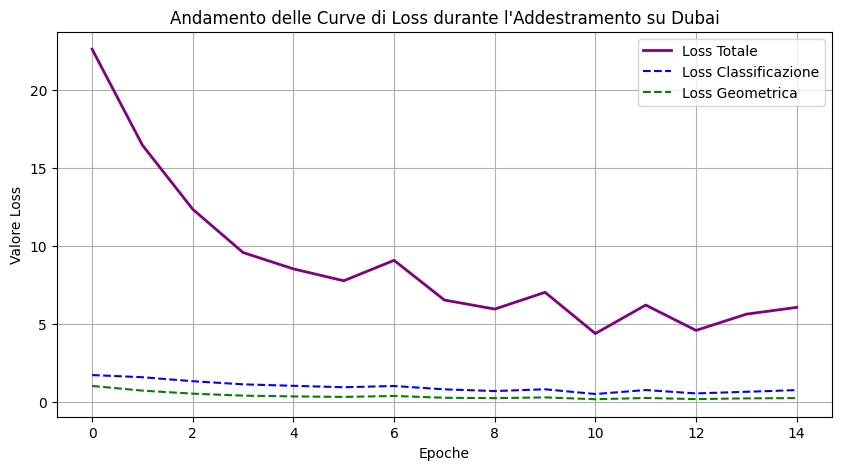

In [15]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. PARAMETRI DI ADDESTRAMENTO
NUM_EPOCHS = 15          # Per fare un test completo e vedere la Loss scendere
LEARNING_RATE = 1e-4      # Velocità di apprendimento standard per i Transformer
BATCH_SIZE = 2

# Re-inizializziamo i componenti essenziali per sicurezza
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PurePyTorchMask2Former(num_classes=6, num_queries=100).to(device)
criterion = Mask2FormerLoss(num_classes=6).to(device)

# Usiamo AdamW, l'ottimizzatore standard dei Transformer che gestisce meglio i pesi
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Liste per salvare la storia della loss e fare il grafico alla fine
history_total_loss = []
history_cls_loss = []
history_geom_loss = []

print(f"🖥️ Addestramento avviato su dispositivo: {device}")
print(f"📊 Numero di epoche impostate: {NUM_EPOCHS}\n" + "-"*50)

# 2. CICLO DI TRAINING GENERALE
for epoch in range(NUM_EPOCHS):
    model.train() # Mettiamo il modello in modalità addestramento
    epoch_total_loss = 0.0
    epoch_cls_loss = 0.0
    epoch_geom_loss = 0.0
    
    # Barra di caricamento visiva per ogni epoca
    loop = tqdm(dubai_dataloader, desc=f"Epoca [{epoch+1}/{NUM_EPOCHS}]", leave=False)
    
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)
        
        # Reset dei gradienti accumulati nel passo precedente
        optimizer.zero_grad()
        
        # Forward pass: il modello fa la sua predizione
        outputs = model(images)
        
        # Calcolo della Loss combinata
        loss, loss_details = criterion(outputs, masks)
        
        # Backpropagation: calcolo dell'errore all'indietro
        loss.backward()
        
        # Protezione anti-gradient explosion (taglio dei gradienti troppo alti)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.01)
        
        # Aggiornamento effettivo dei pesi della rete
        optimizer.step()
        
        # Accumuliamo le loss per le statistiche dell'epoca
        epoch_total_loss += loss.item()
        epoch_cls_loss += loss_details['cls']
        epoch_geom_loss += (loss_details['bce'] + loss_details['dice'])
        
        # Aggiorniamo la stringa informativa sulla barra di caricamento
        loop.set_postfix(loss=loss.item())
        
    # Calcoliamo la media delle loss su tutta l'epoca corrente
    num_batches = len(dubai_dataloader)
    avg_total = epoch_total_loss / num_batches
    avg_cls = epoch_cls_loss / num_batches
    avg_geom = epoch_geom_loss / num_batches
    
    # Salviamo nella storia per il grafico finale
    history_total_loss.append(avg_total)
    history_cls_loss.append(avg_cls)
    history_geom_loss.append(avg_geom)
    
    print(f"📢 Epoca [{epoch+1}/{NUM_EPOCHS}] Completata!")
    print(f"   ↳ 📉 Loss Totale Media: {avg_total:.4f}")
    print(f"   ↳ 📑 Loss Classificazione: {avg_cls:.4f}")
    print(f"   ↳ 📐 Loss Geometrica (BCE+DICE): {avg_geom:.4f}\n" + "-"*30)

# 3. SALVATAGGIO DEI PESI DEL MODELLO ADDESTRATO
torch.save(model.state_dict(), "mask2former_dubai_final.pth")
print("\n💾 PESI DEL MODELLO SALVATI CON SUCCESSO in 'mask2former_dubai_final.pth'!")

# 4. GENERAZIONE AUTOMATICA DEL GRAFICO DELLE LOSS
plt.figure(figsize=(10, 5))
plt.plot(history_total_loss, label='Loss Totale', color='purple', linewidth=2)
plt.plot(history_cls_loss, label='Loss Classificazione', color='blue', linestyle='--')
plt.plot(history_geom_loss, label='Loss Geometrica', color='green', linestyle='--')
plt.title('Andamento delle Curve di Loss durante l\'Addestramento su Dubai')
plt.xlabel('Epoche')
plt.ylabel('Valore Loss')
plt.legend()
plt.grid(True)
plt.show()

📊 Estrazione e accumulo dei pixel su TUTTO il dataset in corso...

📝 --- CLASSIFICATION REPORT GLOBALE (PIXEL-LEVEL) ---
              precision    recall  f1-score   support

   Buildings     0.5510    0.7423    0.6325     34589
       Roads     0.6063    0.3565    0.4490     26544
       Water     0.7626    0.9639    0.8515     61870
        Land     0.8298    0.8553    0.8423    139370
  Vegetation     0.0000    0.0000    0.0000     29162
     Natural     0.0000    0.0000    0.0000      3377

   micro avg     0.7533    0.7255    0.7391    294912
   macro avg     0.4583    0.4863    0.4626    294912
weighted avg     0.6713    0.7255    0.6913    294912


📊 Generazione della Matrice di Confusione Globale...


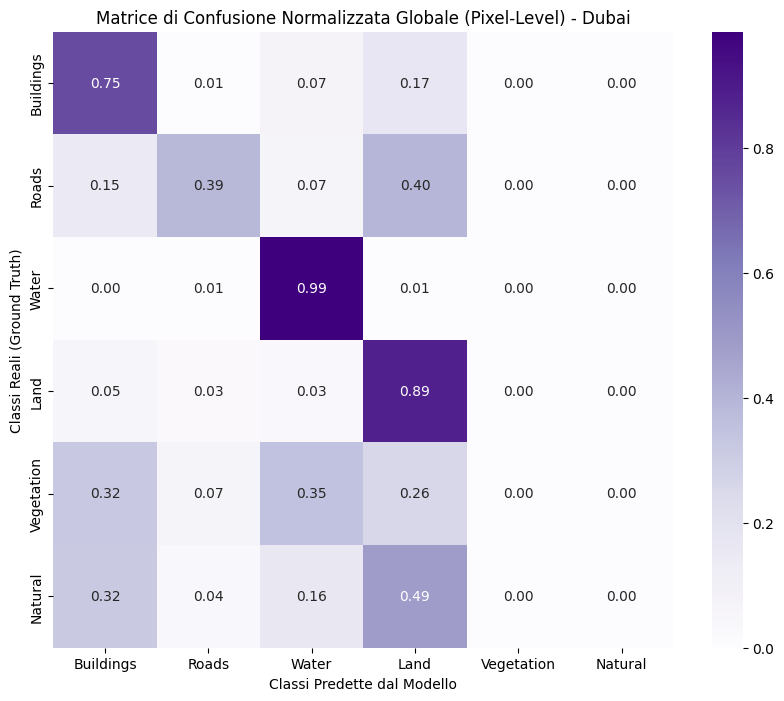

💾 Matrice globale salvata in 'confusion_matrix_dubai_globale.png'!


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_targets = []
class_names = ["Buildings", "Roads", "Water", "Land", "Vegetation", "Natural"]

print("📊 Estrazione e accumulo dei pixel su TUTTO il dataset in corso...")

# Cicliamo su TUTTI i batch del dataloader per raccogliere l'intero volume di dati
with torch.no_grad():
    for images, masks in dubai_dataloader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        pred_masks = outputs['pred_masks'] # [B, 100, 64, 64]
        
        # Ridimensionamento geometrico
        masks_scaled = F.interpolate(
            masks.unsqueeze(1).float(), 
            size=(64, 64), 
            mode='nearest'
        ).squeeze(1).long()
        
        # Argmax spaziale competitivo
        pixel_assignment = torch.argmax(pred_masks, dim=1) # [B, 64, 64]
        pred_logits = outputs['pred_logits'] # [B, 100, 7]
        
        for b in range(images.shape[0]):
            batch_assignment = pixel_assignment[b].cpu().numpy()
            batch_target = masks_scaled[b].cpu().numpy()
            batch_logits = pred_logits[b].cpu().numpy()
            
            pred_class_map = np.argmax(batch_logits, axis=-1)
            batch_pred = pred_class_map[batch_assignment]
            
            # Filtriamo i pixel validi (escludendo lo sfondo vuoto > 5)
            valid_pixels = batch_target < len(class_names)
            
            all_preds.extend(batch_pred[valid_pixels])
            all_targets.extend(batch_target[valid_pixels])

y_true = np.array(all_targets)
y_pred = np.array(all_preds)

print("\n📝 --- CLASSIFICATION REPORT GLOBALE (PIXEL-LEVEL) ---")
report = classification_report(
    y_true, 
    y_pred, 
    labels=list(range(len(class_names))), 
    target_names=class_names, 
    digits=4,
    zero_division=0
)
print(report)

print("\n📊 Generazione della Matrice di Confusione Globale...")
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

# Normalizzazione di sicurezza per riga
row_sums = cm.sum(axis=1)[:, np.newaxis]
row_sums = np.where(row_sums == 0, 1, row_sums)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice di Confusione Normalizzata Globale (Pixel-Level) - Dubai')
plt.xlabel('Classi Predette dal Modello')
plt.ylabel('Classi Reali (Ground Truth)')

plt.savefig("confusion_matrix_dubai_globale.png", dpi=300, bbox_inches='tight')
plt.show()
print("💾 Matrice globale salvata in 'confusion_matrix_dubai_globale.png'!")

In [17]:
# 1. Estraiamo un batch fresco dal dataloader
images, masks = next(iter(dubai_dataloader))
images = images.to(device)

# 2. Vediamo cosa risponde il modello disattivando il calcolo dei gradienti
model.eval()
with torch.no_grad():
    outputs = model(images)

pred_masks = outputs['pred_masks'] # Forma: [Batch, Query, 64, 64]

print("🔍 --- ISPEZIONE DELLE MASCHERE PREDETTE ---")
print(f"Forma del tensore pred_masks: {pred_masks.shape}")

# Analizziamo la primissima query del primo elemento del batch
sample_query_mask = pred_masks[0, 0]

print(f"\nValore Massimo nella mappa: {sample_query_mask.max().item():.4f}")
print(f"Valore Minimo nella mappa: {sample_query_mask.min().item():.4f}")
print(f"Valore Medio nella mappa: {sample_query_mask.mean().item():.4f}")
print(f"Deviazione Standard (varianza dei valori): {sample_query_mask.std().item():.4f}")

# Controlliamo se ci sono valori NaN o Infiniti nascosti nell'output del modello
print(f"\nCi sono NaN nel modello? {torch.isnan(pred_masks).any().item()}")
print(f"Ci sono valori Infiniti? {torch.isinf(pred_masks).any().item()}")

🔍 --- ISPEZIONE DELLE MASCHERE PREDETTE ---
Forma del tensore pred_masks: torch.Size([2, 100, 64, 64])

Valore Massimo nella mappa: 0.3188
Valore Minimo nella mappa: -1.6319
Valore Medio nella mappa: -0.5698
Deviazione Standard (varianza dei valori): 0.3517

Ci sono NaN nel modello? False
Ci sono valori Infiniti? False
